In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Causal-learn PC Algorithm
from causallearn.search.ConstraintBased.PC import pc

# VAR model
from statsmodels.tsa.api import VAR

/Users/isabellamueller-vogt/Library/Mobile Documents/com~apple~CloudDocs/08 - side quests/network-dynamics-failure-propagation/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

# ============================================================
# STAGE 0: LOAD & PREP WEATHER DATA
# ============================================================

# This assumes ghcn_clean.csv from your previous script:
# columns: station, date, variable, value
ghcn_file = "/Users/isabellamueller-vogt/Library/Mobile Documents/com~apple~CloudDocs/08 - side quests/network-dynamics-failure-propagation/model/data/ghcn_clean_small.csv"

print("Loading weather data from:", ghcn_file)
df_long = pd.read_csv(ghcn_file, parse_dates=["date"])

# Keep a specific set of variables
weather_vars = ["TMAX", "TMIN", "PRCP", "SNOW", "SNWD"]
df_long = df_long[df_long["variable"].isin(weather_vars)].copy()

# Pivot to wide format: one row per (station, date)
df_wide = (
    df_long
    .pivot_table(index=["station", "date"],
                 columns="variable",
                 values="value")
    .reset_index()
)

print("Wide dataframe shape (station-date rows):", df_wide.shape)

# Drop rows where any of the chosen vars are missing
df_wide = df_wide.dropna(subset=weather_vars)
print("After dropping NA rows:", df_wide.shape)

Loading weather data from: /Users/isabellamueller-vogt/Library/Mobile Documents/com~apple~CloudDocs/08 - side quests/network-dynamics-failure-propagation/model/data/ghcn_clean_small.csv
Wide dataframe shape (station-date rows): (17692339, 7)
After dropping NA rows: (2749423, 7)


In [3]:
# ============================================================
# STAGE 1: TRAIN/TEST SPLIT (BY LOCATION, NOT TIME)
# ============================================================

print("\nStage 1: Train/Test split by LOCATION (stations)")

test_size = 0.2  # 20% of stations held out
random_state = 42

# 1. Get unique station IDs
stations = df_wide["station"].unique()
print("Total unique stations:", len(stations))

# 2. Split stations into train/test sets
from sklearn.model_selection import train_test_split

train_stations, test_stations = train_test_split(
    stations,
    test_size=test_size,
    random_state=random_state
)

print("Train stations:", len(train_stations))
print("Test stations: ", len(test_stations))

# 3. Split the FULL dataset by station
train_data = df_wide[df_wide["station"].isin(train_stations)].copy()
test_data  = df_wide[df_wide["station"].isin(test_stations)].copy()

print("Train rows (station-days):", train_data.shape[0])
print("Test rows  (station-days):", test_data.shape[0])

# ------------------------------------------------------------
# DATA FOR PC (IID SAMPLES ACROSS LOCATIONS + DAYS)
# ------------------------------------------------------------

df_train_pc = train_data[weather_vars].dropna()
print("\nPC training matrix shape (train stations, all days):", df_train_pc.shape)

# ------------------------------------------------------------
# DATA FOR VAR (AGGREGATED DAILY FIELD OVER TRAIN STATIONS)
# ------------------------------------------------------------

# Aggregate across TRAIN stations by date (spatial mean field)
df_train_ts = (
    train_data
    .groupby("date")[weather_vars]
    .mean()
    .sort_index()
)

df_test_ts = (
    test_data
    .groupby("date")[weather_vars]
    .mean()
    .sort_index()
)

print("\nTime-series (TRAIN, aggregated over locations) shape:", df_train_ts.shape)
print("Time-series (TEST, aggregated over locations) shape: ", df_test_ts.shape)

print("Train date range:", df_train_ts.index.min(), "to", df_train_ts.index.max())
print("Test  date range:", df_test_ts.index.min(), "to", df_test_ts.index.max())



Stage 1: Train/Test split by LOCATION (stations)
Total unique stations: 317
Train stations: 253
Test stations:  64
Train rows (station-days): 2193748
Test rows  (station-days): 555675

PC training matrix shape (train stations, all days): (2193748, 5)

Time-series (TRAIN, aggregated over locations) shape: (48542, 5)
Time-series (TEST, aggregated over locations) shape:  (41473, 5)
Train date range: 1891-03-01 00:00:00 to 2025-12-06 00:00:00
Test  date range: 1895-08-01 00:00:00 to 2025-12-06 00:00:00



Stage 2: Running PC Algorithm on daily samples...


Depth=3, working on node 4: 100%|██████████| 5/5 [00:00<00:00, 623.67it/s] 



Stage 2 Complete: Causal topology discovered.

Directed / candidate parents per variable:
  TMAX: []
  TMIN: ['PRCP', 'TMAX']
  PRCP: []
  SNOW: ['PRCP', 'TMAX']
  SNWD: ['PRCP', 'SNOW', 'TMAX', 'TMIN']


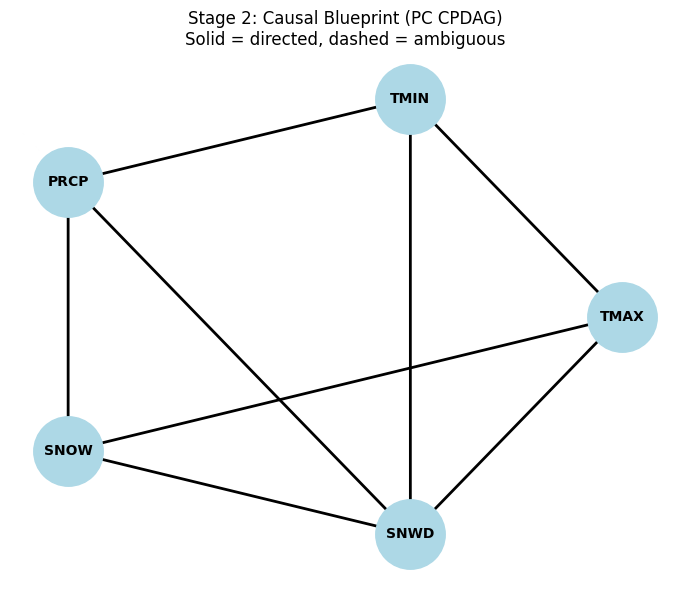

In [4]:

# ============================================================
# STAGE 2: CAUSAL DISCOVERY (PC Algorithm)
# ============================================================

print("\nStage 2: Running PC Algorithm on daily samples...")

data_matrix = df_train_pc.to_numpy()
labels = list(df_train_pc.columns)
n_vars = len(labels)

cg = pc(
    data_matrix,
    alpha=0.05,           # significance threshold
    indep_test='fisherz', # continuous vars
    verbose=False
)

# cg.G is a CPDAG (graph structure)
adj = cg.G.graph  # adjacency matrix

edges = []  # (u, v, edge_type)
parents = {v: set() for v in labels}

for i in range(n_vars):
    for j in range(i + 1, n_vars):
        a_ij = adj[i, j]
        a_ji = adj[j, i]

        if a_ij == 0 and a_ji == 0:
            continue

        # i -> j
        if a_ji == 1 and a_ij == -1:
            u, v, etype = labels[i], labels[j], 'directed'
            edges.append((u, v, etype))
            parents[v].add(u)

        # j -> i
        elif a_ij == 1 and a_ji == -1:
            u, v, etype = labels[j], labels[i], 'directed'
            edges.append((u, v, etype))
            parents[v].add(u)

        # undirected (ambiguous in CPDAG)
        elif a_ij == -1 and a_ji == -1:
            u, v, etype = labels[i], labels[j], 'undirected'
            edges.append((u, v, etype))
            parents[u].add(v)
            parents[v].add(u)

        # bidirected (rare)
        elif a_ij == 1 and a_ji == 1:
            u, v, etype = labels[i], labels[j], 'bidirected'
            edges.append((u, v, etype))
            parents[u].add(v)
            parents[v].add(u)

print("\nStage 2 Complete: Causal topology discovered.\n")
print("Directed / candidate parents per variable:")
for v in labels:
    print(f"  {v}: {sorted(parents[v])}")

# ---- Visualization with networkx ----
G_pc = nx.DiGraph()
G_pc.add_nodes_from(labels)

for u, v, etype in edges:
    if etype == 'directed':
        G_pc.add_edge(u, v, style='solid')
    elif etype in ('undirected', 'bidirected'):
        G_pc.add_edge(u, v, style='dashed')

plt.figure(figsize=(7, 6))
pos = nx.circular_layout(G_pc)

nx.draw_networkx_nodes(G_pc, pos, node_color='lightblue', node_size=2500)
nx.draw_networkx_labels(G_pc, pos, font_weight='bold', font_size=10)

solid_edges = [(u, v) for u, v, d in G_pc.edges(data=True) if d.get('style') == 'solid']
dashed_edges = [(u, v) for u, v, d in G_pc.edges(data=True) if d.get('style') == 'dashed']

nx.draw_networkx_edges(
    G_pc, pos,
    edgelist=solid_edges,
    arrows=True,
    arrowsize=20,
    arrowstyle='-|>',
    edge_color='black',
    width=2
)
nx.draw_networkx_edges(
    G_pc, pos,
    edgelist=dashed_edges,
    arrows=False,
    style='dashed',
    edge_color='gray',
    width=2
)

plt.title("Stage 2: Causal Blueprint (PC CPDAG)\nSolid = directed, dashed = ambiguous")
plt.axis("off")
plt.tight_layout()
plt.show()

In [5]:

# ============================================================
# STAGE 3: TEMPORAL DYNAMICS (VAR Model)
# ============================================================

print("\nStage 3: Fitting VAR model on daily TRAIN series...")

model = VAR(df_train_ts)
results = model.fit(maxlags=7, ic='aic')  # up to 7-day lag, select by AIC
lag_order = results.k_ar
var_names = list(df_train_ts.columns)

print(f"Stage 3 Complete: VAR fitted with lag order = {lag_order}")
print("Variables:", var_names)

coefs = results.coefs  # shape: (lags, n_vars, n_vars)
print("Coefficient tensor shape:", coefs.shape)

# Example: Does higher TMAX affect SNWD (snow depth) over time?
print("\nChecking logic: Does higher TMAX predict changes in SNWD?")

try:
    tmax_idx = var_names.index("TMAX")
    snwd_idx = var_names.index("SNWD")
except ValueError as e:
    raise ValueError("Expected 'TMAX' and 'SNWD' in time-series columns") from e

tmax_to_snwd = []
for lag in range(1, lag_order + 1):
    coef_lag = coefs[lag - 1, snwd_idx, tmax_idx]  # SNWD_t ← TMAX_{t-lag}
    tmax_to_snwd.append(coef_lag)
    sign = "negative (warmer → less snow depth)" if coef_lag < 0 else "positive (warmer → more snow depth)"
    print(f"  Lag {lag}: coef = {coef_lag:.5f} ({sign})")

total_effect = sum(tmax_to_snwd)
print(f"\nTotal TMAX→SNWD effect across {lag_order} lags: {total_effect:.5f} "
      f"({'overall negative' if total_effect < 0 else 'overall positive'})")



Stage 3: Fitting VAR model on daily TRAIN series...


/Users/isabellamueller-vogt/Library/Mobile Documents/com~apple~CloudDocs/08 - side quests/network-dynamics-failure-propagation/venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Stage 3 Complete: VAR fitted with lag order = 7
Variables: ['TMAX', 'TMIN', 'PRCP', 'SNOW', 'SNWD']
Coefficient tensor shape: (7, 5, 5)

Checking logic: Does higher TMAX predict changes in SNWD?
  Lag 1: coef = -0.03573 (negative (warmer → less snow depth))
  Lag 2: coef = -0.00957 (negative (warmer → less snow depth))
  Lag 3: coef = 0.03090 (positive (warmer → more snow depth))
  Lag 4: coef = -0.01935 (negative (warmer → less snow depth))
  Lag 5: coef = -0.00103 (negative (warmer → less snow depth))
  Lag 6: coef = 0.01003 (positive (warmer → more snow depth))
  Lag 7: coef = -0.00581 (negative (warmer → less snow depth))

Total TMAX→SNWD effect across 7 lags: -0.03055 (overall negative)



Stage 4: Visualizing lag-1 coefficient matrix...


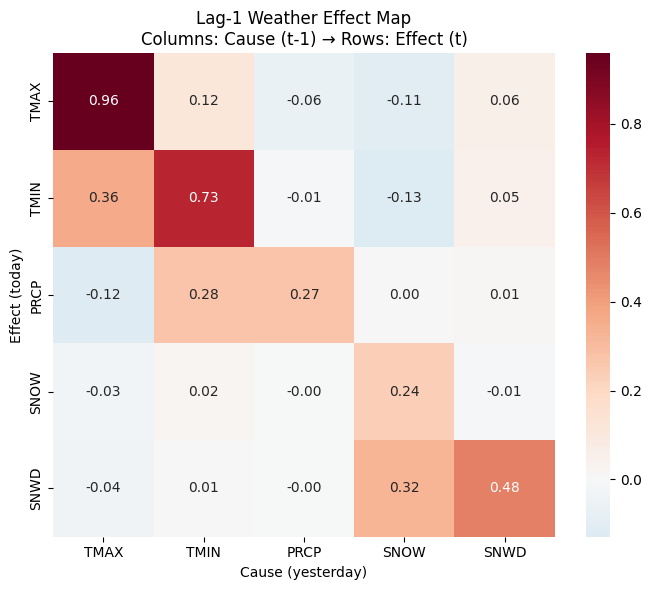

In [6]:

# ============================================================
# STAGE 4: VISUALIZE LAG-1 COEFFICIENT MATRIX
# ============================================================

print("\nStage 4: Visualizing lag-1 coefficient matrix...")

if lag_order >= 1:
    matrix_l1 = pd.DataFrame(
        coefs[0],
        index=var_names,   # rows: effect at time t
        columns=var_names  # cols: cause at time t-1
    )

    plt.figure(figsize=(7, 6))
    sns.heatmap(matrix_l1, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
    plt.title("Lag-1 Weather Effect Map\nColumns: Cause (t-1) → Rows: Effect (t)")
    plt.ylabel("Effect (today)")
    plt.xlabel("Cause (yesterday)")
    plt.tight_layout()
    plt.show()
else:
    print("Model chose lag_order = 0: no temporal structure to visualize.")



Stage 5: Running baseline vs intervention simulations...


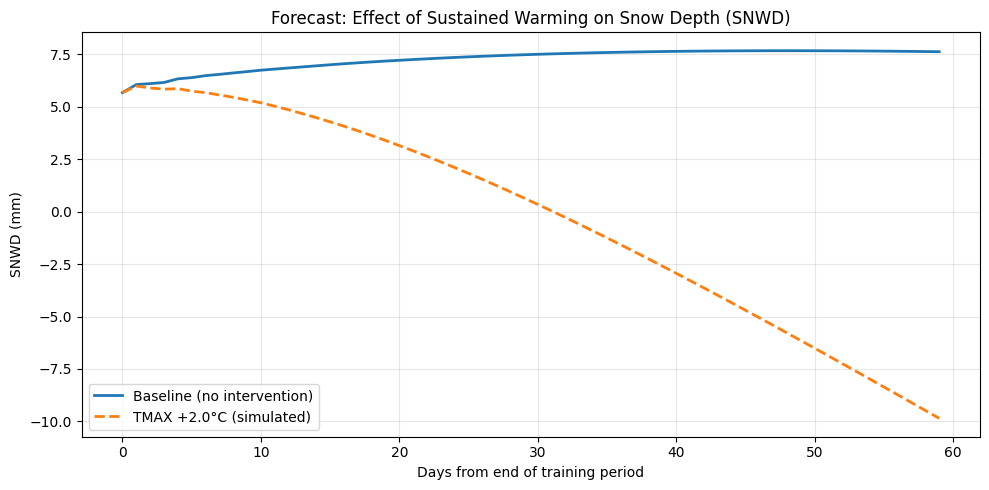


TMAX → SNWD critical-threshold analysis (loss of snowpack):
  Critical threshold (SNWD <=) = 10.0 mm
  Baseline crossing day:     0
  Intervention crossing day: 0
  → Under this setup, warming does not cause earlier snow loss than baseline.


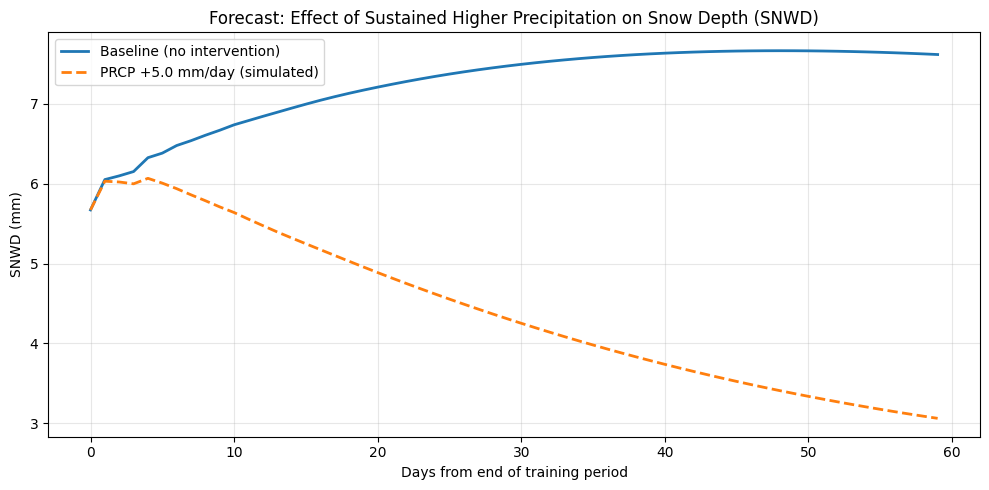

In [8]:
# ============================================================
# STAGE 5: INTERVENTION SIMULATION (Baseline vs Policy Path)
# ============================================================

print("\nStage 5: Running baseline vs intervention simulations...")

var_names = list(df_train_ts.columns)
k_ar = results.k_ar

# -------------------------------------------------------------------
# Helper: generic forward simulation of the VAR
# -------------------------------------------------------------------
def simulate_path(results, initial_history, horizon, intervention_fn=None):
    """
    Simulate a path of length `horizon` from a VAR model.

    initial_history : ndarray, shape = (k_ar, n_vars)
        Last k_ar observations (in correct time order).
    intervention_fn : callable or None
        Function f(step_idx, y_pred) -> modified_y_pred.
        Called at each step *after* the VAR one-step prediction.
        If None, no intervention is applied.
    """
    history = initial_history.copy()
    n_vars = history.shape[1]
    path = []

    for step in range(horizon):
        # One-step-ahead forecast from current history
        y_pred = results.forecast(y=history, steps=1)[0]  # shape (n_vars,)

        # Apply intervention (policy) if provided
        if intervention_fn is not None:
            y_pred = intervention_fn(step, y_pred.copy())

        path.append(y_pred)

        # Roll history window forward: drop oldest, append new
        history = np.vstack([history[1:], y_pred])

    return np.array(path)  # shape (horizon, n_vars)


# -------------------------------------------------------------------
# Helper: detect when a trajectory crosses a critical threshold
# -------------------------------------------------------------------
def first_crossing(series, threshold, direction="above"):
    """
    Return the first time index t where series crosses threshold.

    direction: 'above' for series[t] >= threshold
               'below' for series[t] <= threshold
    Returns None if never crosses.
    """
    if direction == "above":
        mask = series >= threshold
    else:
        mask = series <= threshold

    idx = np.argmax(mask)  # index of first True OR 0
    return int(idx) if mask.any() else None


# -------------------------------------------------------------------
# Setup simulation parameters
# -------------------------------------------------------------------
horizon = 60  # e.g., project 60 days into the future

# Last k_ar observations from TRAIN set as starting state
initial_history = df_train_ts.values[-k_ar:, :]

# -------------------------------------------------------------------
# Scenario 1: "What if it were consistently 2°C warmer each day?" (TMAX ↑)
# -------------------------------------------------------------------
if "TMAX" in var_names and "SNWD" in var_names:
    tmax_idx = var_names.index("TMAX")
    snwd_idx = var_names.index("SNWD")

    # Baseline: no intervention
    baseline_path = simulate_path(results, initial_history, horizon, intervention_fn=None)

    # Policy: sustained warming – add +2°C to TMAX each day
    temp_boost = 2.0  # degrees C

    def warmer_climate(step, y_pred):
        y_pred[tmax_idx] += temp_boost
        return y_pred

    intervention_path = simulate_path(results, initial_history, horizon, intervention_fn=warmer_climate)

    # Plot trajectories for SNWD (snow depth)
    t = np.arange(horizon)
    plt.figure(figsize=(10, 5))
    plt.plot(t, baseline_path[:, snwd_idx], label="Baseline (no intervention)", linewidth=2)
    plt.plot(t, intervention_path[:, snwd_idx], label=f"TMAX +{temp_boost}°C (simulated)", linewidth=2, linestyle="--")
    plt.xlabel("Days from end of training period")
    plt.ylabel("SNWD (mm)")
    plt.title("Forecast: Effect of Sustained Warming on Snow Depth (SNWD)")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Optional: critical snow depth threshold, e.g. SNWD <= 10 mm = "no snow"
    critical_threshold = 10.0
    base_cross = first_crossing(baseline_path[:, snwd_idx], critical_threshold, direction="below")
    intv_cross = first_crossing(intervention_path[:, snwd_idx], critical_threshold, direction="below")

    print("\nTMAX → SNWD critical-threshold analysis (loss of snowpack):")
    print(f"  Critical threshold (SNWD <=) = {critical_threshold} mm")
    print(f"  Baseline crossing day:     {base_cross}")
    print(f"  Intervention crossing day: {intv_cross}")
    if base_cross is not None and (intv_cross is None or intv_cross < base_cross):
        print("  → Warming causes snowpack to be lost earlier than baseline.")
    elif base_cross is None and intv_cross is not None:
        print("  → Baseline keeps snow, but warming eliminates it within the horizon.")
    else:
        print("  → Under this setup, warming does not cause earlier snow loss than baseline.")

# -------------------------------------------------------------------
# Scenario 2: "What if daily precipitation were higher?" (PRCP ↑)
# -------------------------------------------------------------------
if "PRCP" in var_names and "SNWD" in var_names:
    prcp_idx = var_names.index("PRCP")
    snwd_idx = var_names.index("SNWD")

    baseline_path2 = simulate_path(results, initial_history, horizon, intervention_fn=None)

    # Policy: sustained increase in daily precipitation
    prcp_boost = 5.0  # mm/day more precipitation (conceptual)
    def wetter_climate(step, y_pred):
        y_pred[prcp_idx] += prcp_boost
        return y_pred

    intervention_path2 = simulate_path(results, initial_history, horizon, intervention_fn=wetter_climate)

    t = np.arange(horizon)
    plt.figure(figsize=(10, 5))
    plt.plot(t, baseline_path2[:, snwd_idx], label="Baseline (no intervention)", linewidth=2)
    plt.plot(t, intervention_path2[:, snwd_idx], label=f"PRCP +{prcp_boost} mm/day (simulated)", linewidth=2, linestyle="--")
    plt.xlabel("Days from end of training period")
    plt.ylabel("SNWD (mm)")
    plt.title("Forecast: Effect of Sustained Higher Precipitation on Snow Depth (SNWD)")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("\nSkipping some intervention scenarios because required variables were not found.")


Stage 6: Validation on held-out test period (aggregated over locations)...


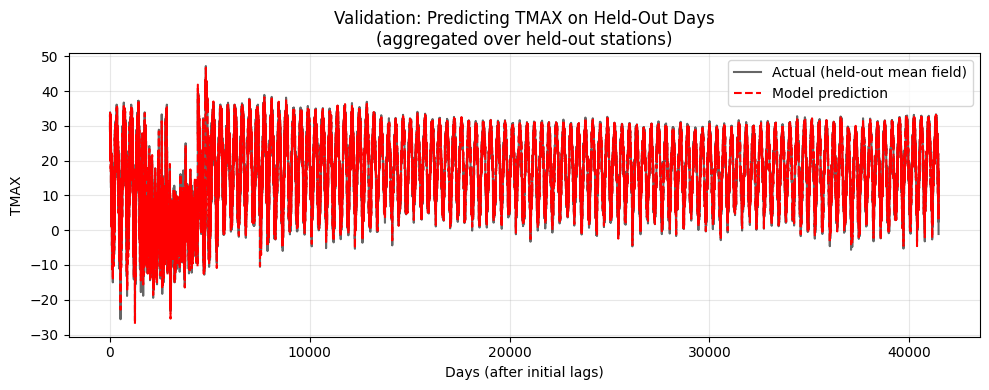

Validation RMSE on 'TMAX' (test days): 2.245


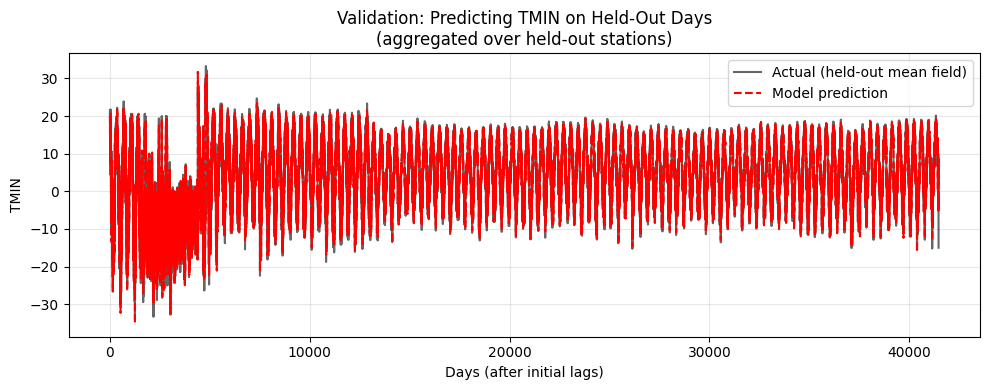

Validation RMSE on 'TMIN' (test days): 2.080


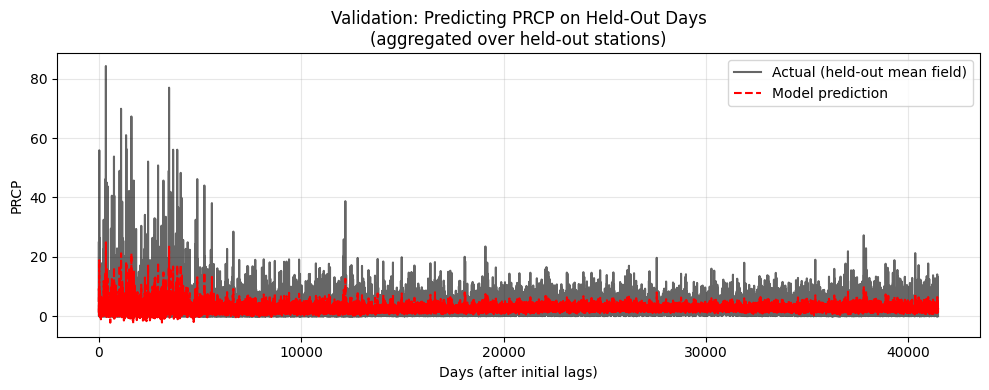

Validation RMSE on 'PRCP' (test days): 3.158


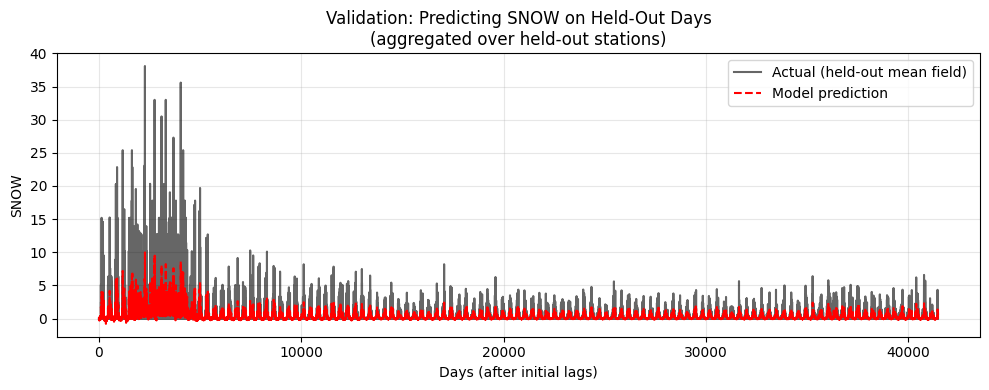

Validation RMSE on 'SNOW' (test days): 1.144


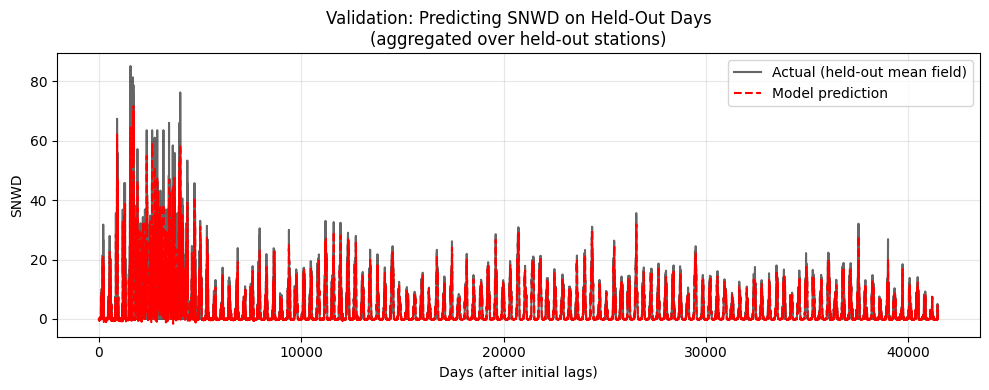

Validation RMSE on 'SNWD' (test days): 2.709


In [9]:
# ============================================================
# STAGE 6: FORECASTING & VALIDATION ON HELD-OUT PERIOD
# ============================================================

print("\nStage 6: Validation on held-out test period (aggregated over locations)...")

def validate_var_on_heldout(df_test_ts, results, targets=None):
    """
    Validate a fitted VAR model on a held-out time period (df_test_ts).

    df_test_ts : DataFrame
        Test time series with datetime index and columns matching the VAR model.
    results    : VARResults
        Fitted VAR model.
    targets    : list[str] or None
        Which variables to validate/plot. If None, validate all columns.
    """
    var_names = list(df_test_ts.columns)
    if targets is None:
        targets = var_names
    else:
        # only keep targets that actually exist in the data
        targets = [t for t in targets if t in var_names]

    if not targets:
        print("No valid target variables found in df_test_ts; nothing to validate.")
        return

    test_values = df_test_ts.values
    lag_order = results.k_ar

    if len(test_values) <= lag_order:
        print("Not enough test points after lag_order to perform validation.")
        return

    # Build rolling forecasts over the test period
    predictions = []
    actuals = []

    for t_step in range(lag_order, len(test_values)):
        # last `lag_order` observations from TEST group
        hist = test_values[t_step - lag_order:t_step]
        pred = results.forecast(y=hist, steps=1)
        predictions.append(pred[0])
        actuals.append(test_values[t_step])

    pred_df = pd.DataFrame(predictions, columns=var_names)
    act_df = pd.DataFrame(actuals, columns=var_names)

    # Compute and plot for each target variable
    for target in targets:
        plt.figure(figsize=(10, 4))
        limit = len(pred_df)
        plt.plot(
            act_df[target].values[:limit],
            label="Actual (held-out mean field)",
            color="black",
            alpha=0.6,
        )
        plt.plot(
            pred_df[target].values[:limit],
            label="Model prediction",
            color="red",
            linestyle="--",
        )
        plt.title(f"Validation: Predicting {target} on Held-Out Days\n"
                  f"(aggregated over held-out stations)")
        plt.xlabel("Days (after initial lags)")
        plt.ylabel(target)
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

        rmse = np.sqrt(mean_squared_error(act_df[target], pred_df[target]))
        print(f"Validation RMSE on '{target}' (test days): {rmse:.3f}")


# ---- Call the function for multiple weather variables ----
targets_to_check = ["TMAX", "TMIN", "PRCP", "SNOW", "SNWD"]
validate_var_on_heldout(df_test_ts, results, targets=targets_to_check)
